In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models
from src.utils import (
    load_animal_data, ANIMAL_CLASSES, ANIMAL_INDICES,
    prepare_data, make_test_loader, export_model, PROJECT_ROOT
)
from src.train import train_model
from src.evaluate import evaluate_model, plot_history, export_metrics

/Users/antoinegobbe/Desktop/Plateforme/neuralzoo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
X_train, y_train, X_test, y_test = load_animal_data()

train_loader, val_loader = prepare_data(X_train, y_train, ANIMAL_INDICES)
test_loader              = make_test_loader(X_test, y_test, ANIMAL_INDICES)

/Users/antoinegobbe/Desktop/Plateforme/neuralzoo/src/utils.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding='bytes')


**Problème natif de ResNet-18 avec CIFAR-10**

ResNet-18 a été conçu pour ImageNet — des images 224×224. Sa première couche est une convolution 7×7 avec stride 2, suivie d'un MaxPool. Sur des images 32×32, ça écrase l'information dès le début : tu passes de 32×32 à 8×8 en deux opérations. Le modèle ne "voit" presque rien.
La solution standard pour CIFAR c'est de modifier les deux premières couches

In [9]:
def build_resnet_cifar(num_classes=6):
    model = models.resnet18(weights=None)
    
    # Remplace conv1 7x7 stride 2 → conv 3x3 stride 1
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    # Supprime le MaxPool qui écrase trop
    model.maxpool = nn.Identity()
    # Adapte la couche finale au nombre de classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

resnet = build_resnet_cifar(num_classes=6)
print(resnet)
print(f"\nNombre de paramètres : {sum(p.numel() for p in resnet.parameters()):,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

Device : mps


Epoch 01/50 — loss: 1.2855 — val_loss: 1.1214 — val_acc: 0.5840


Epoch 02/50 — loss: 0.8842 — val_loss: 0.9808 — val_acc: 0.6357


Epoch 03/50 — loss: 0.6795 — val_loss: 0.7168 — val_acc: 0.7413


Epoch 04/50 — loss: 0.5371 — val_loss: 0.8507 — val_acc: 0.7053


...

Epoch 11/50 — loss: 0.0726 — val_loss: 0.9210 — val_acc: 0.7770


Epoch 12/50 — loss: 0.0661 — val_loss: 1.0279 — val_acc: 0.7690


Epoch 13/50 — loss: 0.0535 — val_loss: 0.9757 — val_acc: 0.7823


Epoch 14/50 — loss: 0.0713 — val_loss: 0.9883 — val_acc: 0.7893


Epoch 15/50 — loss: 0.0445 — val_loss: 1.0327 — val_acc: 0.7877
Early stopping à l'epoch 15


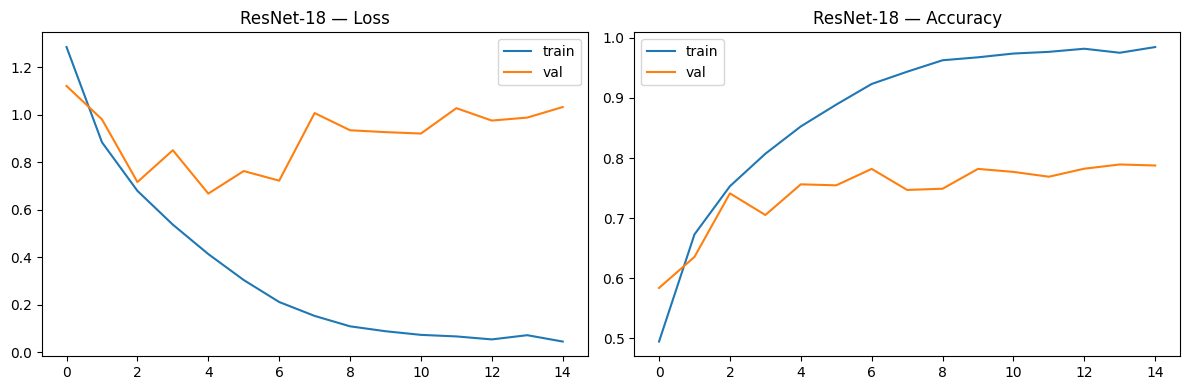

In [10]:
history_resnet = train_model(
    resnet,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
    checkpoint_name="best_resnet.pth"
)
plot_history(history_resnet, 'ResNet-18')

In [11]:
resnet.load_state_dict(
    torch.load(PROJECT_ROOT / "models" / "best_resnet.pth", weights_only=True)
)

<All keys matched successfully>

              precision    recall  f1-score   support

        bird       0.75      0.77      0.76      1000
         cat       0.59      0.73      0.65      1000
        deer       0.89      0.67      0.76      1000
         dog       0.71      0.76      0.73      1000
        frog       0.85      0.86      0.86      1000
       horse       0.91      0.80      0.85      1000

    accuracy                           0.77      6000
   macro avg       0.78      0.77      0.77      6000
weighted avg       0.78      0.77      0.77      6000



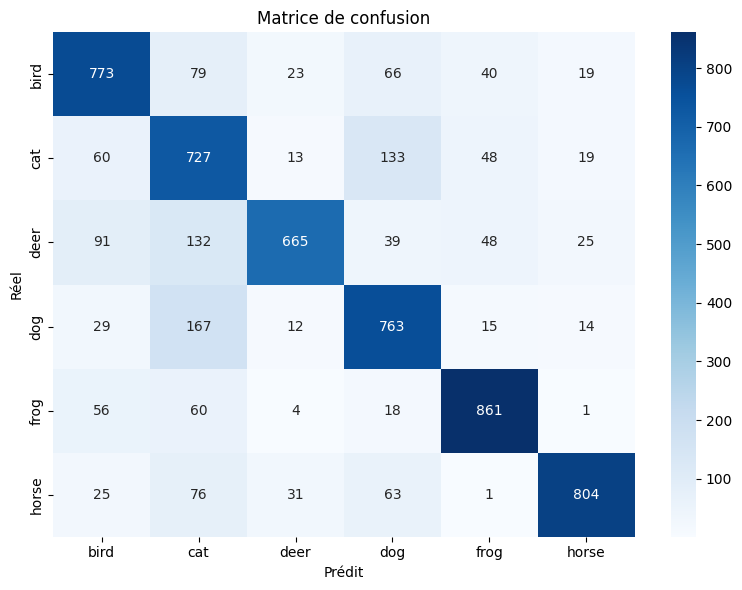

In [12]:
preds, labels = evaluate_model(resnet, test_loader, list(ANIMAL_CLASSES.keys()))

In [13]:
export_metrics(history_resnet, preds, labels, list(ANIMAL_CLASSES.keys()),
               path=PROJECT_ROOT / "models" / "metrics_resnet.json")
export_model(resnet, path=PROJECT_ROOT / "models" / "resnet_cifar10.pth")

Métriques exportées → /Users/antoinegobbe/Desktop/Plateforme/neuralzoo/models/metrics_resnet.json
Modèle exporté → /Users/antoinegobbe/Desktop/Plateforme/neuralzoo/models/resnet_cifar10.pth


## Conclusion — ResNet-18

ResNet-18 a été entraîné sur le même sous-ensemble animal de CIFAR-10 avec une architecture modifiée pour les images 32×32 : remplacement de la convolution d'entrée 7×7 par une 3×3 sans stride, et suppression du MaxPool initial qui écrasait trop l'information spatiale sur des petites images.

**Résultats : 77% d'accuracy test, early stopping à l'epoch 15**

ResNet améliore l'accuracy de 2 points par rapport au CNN custom (77% vs 75%), avec de meilleures performances sur dog (73% F1 vs 70%) et cat (65% F1 stable). Frog et horse restent les classes les mieux reconnues dans les deux modèles.

**Overfitting massif**

La courbe d'entraînement révèle un problème majeur : la train_loss tombe vers 0.04 pendant que la val_loss remonte au-delà de 1.0 dès l'epoch 7. La train_accuracy atteint 97% quand la val_accuracy plafonne à 79%. ResNet-18 compte 11 millions de paramètres pour seulement 27 000 images d'entraînement — le ratio paramètres/données est trop défavorable. Le modèle mémorise le jeu d'entraînement au lieu de généraliser.

**Comparaison finale des trois modèles**

| Modèle     | Accuracy test | F1 macro | Early stopping | Overfitting |
|------------|--------------|----------|----------------|-------------|
| MLP        | ~51%         | ~0.51    | Epoch 18/30    | Sévère      |
| CNN custom | 75%          | 0.75     | Epoch 25/30    | Contrôlé    |
| ResNet-18  | 77%          | 0.77     | Epoch 15/50    | Massif      |

**Choix final**

Malgré son accuracy légèrement supérieure, ResNet-18 n'est pas retenu pour le déploiement. Son overfitting massif indique que le modèle ne généralise pas de manière fiable — les 2 points de gain sur le test set ne compensent pas l'instabilité observée. Le CNN custom offre un meilleur équilibre entre performance et généralisation sur ce volume de données.

Pour améliorer ResNet sur ce dataset, plusieurs pistes existent : data augmentation (rotations, flips, color jitter), weight decay plus agressif, ou learning rate scheduling avec warm restarts. Ces techniques permettraient de contraindre le modèle et de réduire l'écart train/val — mais elles dépassent le cadre de ce projet.

Le CNN custom est retenu comme modèle de production, exporté sous `models/cnn_cifar10.pth` et chargé par l'API FastAPI pour la classification en temps réel.